In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad
from scipy.optimize import brentq

In [7]:
def magnitude(r: np.array) -> float:
    squared = 0
    for _, e in enumerate(r):
        squared += e*e
    
    return np.sqrt(squared)

def cross2d(r1: np.array, r2: np.array) -> float:
    return r1[0] * r2[1] - r1[1] * r2[0]

In [183]:
G = 1
dt = 0.01
steps = 25000

epsilon = 0.0001

m1 = 5
m2 = 1
M = m1+m2
mu = (m1*m2) / M

In [ ]:
# determine initial condition for initial seperating to r_outer to collision
# E < 0, M_z = 0 (ensure v only has radial component), initial dr/dt must be positive -> r_dot dot r_hat > 0

r = np.array([10, 0])
r_mag = magnitude(r)
u = np.sqrt(2*G*M / r_mag) / 4
v = np.array([u, 0])

R_com = np.zeros(0, 0)
V_com = np.zeros(0, 0)

In [ ]:
#determine initial conditions for r_critical case
r_c = 5
r = np.array([r_c, 0])
r_mag = magnitude(r)

b = np.sqrt(G * m1 * m2 / (mu * r_c))
v = np.array([0, b])

R_com = np.zeros(0, 0)
V_com = np.zeros(0, 0)

In [ ]:
#initial conditions for r_inner to infinity case
buffer = 5
r = np.array([20, 0])
r_mag = magnitude(r)
r_dot_y = 20
r_dot_x_squared = ((G * m1 * m2 / r_mag - (mu * r[0] * r_dot_y)**2 / (2 * mu * r_mag ** 2)) * 2/mu - r_dot_y**2) / buffer
r_dot_x = -np.sqrt(abs(r_dot_x_squared))
v = np.array([r_dot_x, r_dot_y])

R_com = np.zeros(0, 0)
V_com = np.zeros(0, 0)

In [164]:
p_initial_m1 = m2 / M * r + R_com
p_initial_m2 = R_com - m1 / M * r
v_initial_m1 = m2 / M * v + V_com
v_initial_m2 = V_com - m1 / M * v

In [184]:
p_initial_m1 = np.array([-1, 0])
p_initial_m2 = np.array([1, 0])
v_initial_m1 = np.array([0, 1])
v_initial_m2 = np.array([0, -1])

In [216]:
r_i = p_initial_m1 - p_initial_m2
r_dot_i = v_initial_m1 - v_initial_m2
R_com_i = (p_initial_m1 * m1 + p_initial_m2 * m2) / M
V_com_i = (v_initial_m1 * m1 + v_initial_m2 * m2) / M

theta_i = np.atan2(r_i[1], r_i[0])

r_mag_i = magnitude(r_i)
L_com = mu * (r_i[0] * r_dot_i[1] - r_i[1] * r_dot_i[0])
print("Lcom:", L_com)

def Veff(r_mag):
    if r_mag == 0:
        raise ZeroDivisionError
    return np.dot(L_com, L_com) / (2 * mu * r_mag**2) - (G*m1*m2 / r_mag)

def dVeff_dr(r_mag):
    return -np.dot(L_com, L_com) / (mu * r_mag**3) + G * m1 * m2 / r_mag**2

def radial_speed_signed(r, v):
    return np.dot(r, v) / magnitude(r)

Veff_i = Veff(r_mag_i)
E = 1/2 * mu * radial_speed_signed(r_i, r_dot_i)**2 + Veff_i
print("E:", E)
print("Veff_i:", Veff_i)

# r_critical should be equivalent to brentq(dVeff_dr, epsilon, 100)

def initial_direction():
    
    direction = np.dot(r_dot_i, r_i)
    if direction == 0:
        return -dVeff_dr(r_mag_i)
    
    return np.sign(direction)

r_critical = None
A = None
theta_phase = None
if not np.isclose(L_com, 0):
    r_critical = np.dot(L_com, L_com) / mu * 1 / (G * m1 * m2)
    A = np.sqrt((1/r_mag_i - 1 / r_critical) ** 2 + (-mu * radial_speed_signed(r_i, r_dot_i) / L_com) ** 2)
    theta_phase = theta_i - np.atan2(-mu * radial_speed_signed(r_i, r_dot_i) / L_com, 1/r_mag_i - 1 / r_critical)

print("A:", A)
print("theta_phase:", theta_phase)

Lcom: -3.3333333333333335
E: -0.8333333333333333
Veff_i: -0.8333333333333333
A: 0.12500000000000006
theta_phase: 3.141592653589793


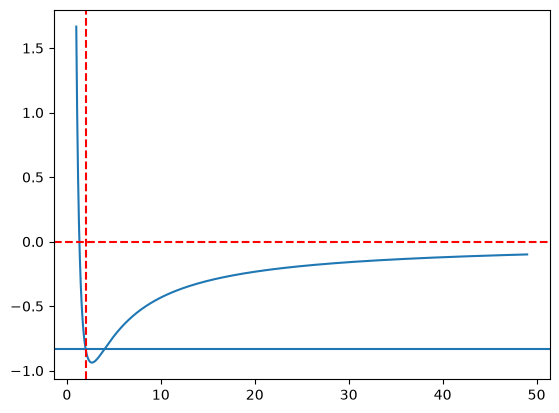

In [198]:
vals = np.linspace(1, 49, 1000)

plt.plot(vals, [Veff(x) for x in vals])
plt.axhline(E)
plt.axhline(0, ls='--', c='r')
plt.axvline(r_mag_i, ls='--', c='r')

In [ ]:
#identify radial turning points (where E = Veff)

def radial_kinetic_energy(r_mag):
    return E - Veff(r_mag)

def turning_points():
    
    #collision case
    if np.isclose(L_com, 0):
        if E < 0:
            r_outer = -G*m1*m2 / E
            return {
                "inner": None,
                "outer": r_outer
            }
            
        return {
            "inner": None,
            "outer": None
        }
    
    #radial case
    if np.isclose(dVeff_dr(r_mag_i), 0) and np.isclose(radial_speed_signed(r_i, r_dot_i), 0):
        return {
            "inner": None,
            "outer": None
        }
        
    inner_bound = r_critical / 2
    while radial_kinetic_energy(inner_bound) > 0:
        inner_bound /= 2
        
    inner = brentq(radial_kinetic_energy, inner_bound, r_critical)
    
    if E >= 0:
        return {
            "inner": inner,
            "outer": None
        }
        
    outer_bound = r_critical * 2
    while radial_kinetic_energy(outer_bound) > 0:
        outer_bound *= 2
        
    outer = brentq(radial_kinetic_energy, r_critical, outer_bound)
        
    return {
        "inner": inner, 
        "outer": outer
    }

In [222]:
collision_detection_radius = 0.01
    
    

tp = turning_points()

def radial_speed_unsigned(r_mag):
    if E - Veff(r_mag) < 0:
        print("sqrt value", 2 / mu * (E - Veff(r_mag)))
        raise ValueError
    return np.sqrt(2 / mu * (E - Veff(r_mag)))

def dt_dr(r_mag):
    return float(1 / radial_speed_unsigned(r_mag))

def integrand(r_initial_mag: float, r_final_mag: float):
    I, _ = quad(dt_dr, r_initial_mag, r_final_mag)
    return I

def bracked_outer_radius(r, t_elapsed):
    outer = max(r * 2, 1)
    
    while integrand(r, outer) < t_elapsed:
        outer *= 2
        
    return outer

def collide_from_initial_r(t):
    time_to_collision = integrand(collision_detection_radius, r_mag_i)
    if t >= time_to_collision:
        print("collided at", time_to_collision)
        return {
            "r": 0,
            "theta": theta_i,
            "collided": True
        }
    
    r = brentq(lambda r: integrand(r, r_mag_i) - t, collision_detection_radius, r_mag_i)
    return {
        "r": r,
        "theta": theta_i
    }

def theta(inward: bool, n_half_cycles: int, r: float) -> float:  
    cw = L_com < 0
    s = -1 if cw else 1
    n_cycles = n_half_cycles // 2
    if inward:
        if n_half_cycles <= 0:
            theta = -np.arccos((1/r - 1/r_critical) / A) * s + theta_phase
        else:
            theta = (2*np.pi-np.arccos((1/r - 1/r_critical) / A)) * s + theta_phase
            
    else:
        theta = np.arccos((1/r - 1/r_critical) / A) * s + theta_phase

    return float(s * 2*np.pi*n_cycles + theta)
        
        

def radius_at_time(t):
    if np.isclose(L_com, 0):
        print("collision case")
        #if unbounded collisions, need to determine initial direction, we are either going to collide, or never collide
        if tp["outer"] == None:
            print("unbounded collision")
            if initial_direction() > 0:
                print("to infinity and beyond")
                outer_upper_bound = bracked_outer_radius(r_mag_i, t)
                r = brentq(lambda r: integrand(r_mag_i, r) - t, r_mag_i, outer_upper_bound)
                return {
                    "r": r,
                    "theta": theta_i
                }
            else:
                print("colliding")
                return collide_from_initial_r(t)
        
        #if r_outer bounded collision
        #if r approach r_outer (initial direction > 0), go to r_outer, then go to collision
        if initial_direction() > 0:
            print("bounded collision")
            time_to_outer = integrand(r_mag_i, tp["outer"])
            if t < time_to_outer:
                r = brentq(lambda r: integrand(r_mag_i, r) - t, r_mag_i, tp["outer"])
                return {
                    "r": r,
                    "theta": theta_i
                }
            
            time_to_collision_from_outer = integrand(collision_detection_radius, tp["outer"])
            if t - time_to_outer >= time_to_collision_from_outer:
                print("collided at after reaching outer", time_to_outer + time_to_collision_from_outer)
                return {
                    "r": 0,
                    "theta": 0,
                    "collided": True
                }
            
            r = brentq(lambda r: -integrand(tp["outer"], r) - (t - time_to_outer), tp["outer"], collision_detection_radius)
            return {
                "r": r,
                "theta": theta_i
            }
        
        #if r apprach inner (initial direction < 0), go to collision
        return collide_from_initial_r(t)
    
    #circular radius case
    if np.isclose(dVeff_dr(r_mag_i), 0) and np.isclose(radial_speed_signed(r_i, r_dot_i), 0):
        r = r_critical
        angle = L_com / (mu * r_critical ** 2) * t + theta_i
        return {
            "r": r,
            "theta": angle
        }
        

    if E >= 0:
        #must consider if initial direction is going inward (to inner turning point then back out) or outward (to infinity and beyond)
        if initial_direction() > 0:
            outer_upper_bound = bracked_outer_radius(r_mag_i, t)
            r = brentq(lambda r: integrand(r_mag_i, r) - t, tp["inner"], outer_upper_bound)
            angle = theta(False, 0, r)
            return {
                "r": r,
                "theta": angle
            }
        
        #get to inner turning point
        time_to_inner = integrand(tp["inner"], r_mag_i)
        if t <= time_to_inner:
            r = brentq(lambda r: integrand(r, r_mag_i) - t, tp["inner"], r_mag_i)
            angle = theta(True, 0, r)
            return {
                "r": r,
                "theta": angle
            }
        
        outer_upper_bound = bracked_outer_radius(r_mag_i, t)
        r = brentq(lambda r: integrand(tp["inner"], r) - (t - time_to_inner), tp["inner"], outer_upper_bound)
        angle = theta(False, 0, r)
        return {
            "r": r,
            "theta": angle
        }
        
        
    half_period = integrand(tp["inner"], tp["outer"])
    t_from_rmin = integrand(tp["inner"], r_mag_i)
    if initial_direction() > 0:
        initial_time = t_from_rmin
    else:
        initial_time = 2 * half_period - t_from_rmin
    
    curr_cycle = (t + initial_time) % (2 * half_period)
    n_half_cycles = (t + initial_time) // (half_period)
    
    
    if curr_cycle > half_period: #returning to r_min (going inward)
            r = brentq(lambda r: integrand(tp["inner"], r) - (2 * half_period - curr_cycle), tp["inner"], tp["outer"])
            angle = theta(True, n_half_cycles, r)
            return {
                "r": r,
                "theta": angle
            }
    r = brentq(lambda r: integrand(tp["inner"], r) - curr_cycle, tp["inner"], tp["outer"])
    angle = theta(False, n_half_cycles, r)
    return {
        "r": r,
        "theta": angle
    }

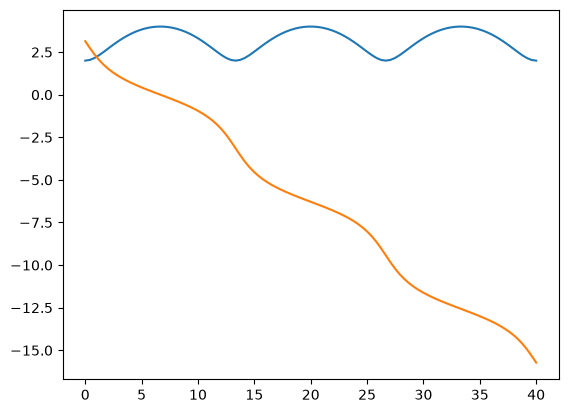

In [223]:
t_values = np.linspace(0, 40, 100)

r_data = []
theta_data = []

p_m1_x = []
p_m1_y = []

for i in range(t_values.size):
    t = t_values[i]
    position = radius_at_time(t)
    R_t = R_com_i + V_com_i * t
    r_data.append(position["r"])
    theta_data.append(position["theta"])
    p_m1_x.append(m2 / M * position["r"] * np.cos(position["theta"]) + R_com)
    p_m1_y.append(m2 / M * position["r"] * np.sin(position["theta"]) + R_com)
    

plt.plot(t_values, r_data)
plt.plot(t_values, theta_data)
# plt.plot(p_m1_x, p_m1_y)

/var/folders/d2/jqp6s4g127sc72bbvlgt80kw0000gn/T/ipykernel_68792/4040854582.py:2: RuntimeWarning: invalid value encountered in scalar divide
  theta_dot_analytic = [L_com / (mu * r**2) for r in r_data]


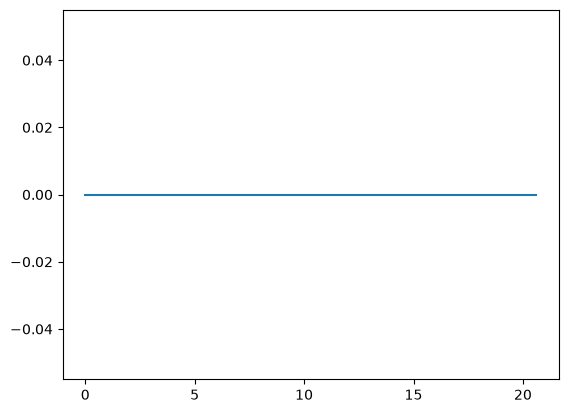

In [182]:
theta_dot_numeric = np.gradient(theta_data, t_values)
theta_dot_analytic = [L_com / (mu * r**2) for r in r_data]
residual = np.array(theta_dot_numeric) - np.array(theta_dot_analytic)
plt.plot(t_values, residual)